<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
pd_train = pd.read_csv("https://raw.githubusercontent.com/thuynguyenhuit/hocsau/refs/heads/main/train.csv")

(1460, 81)


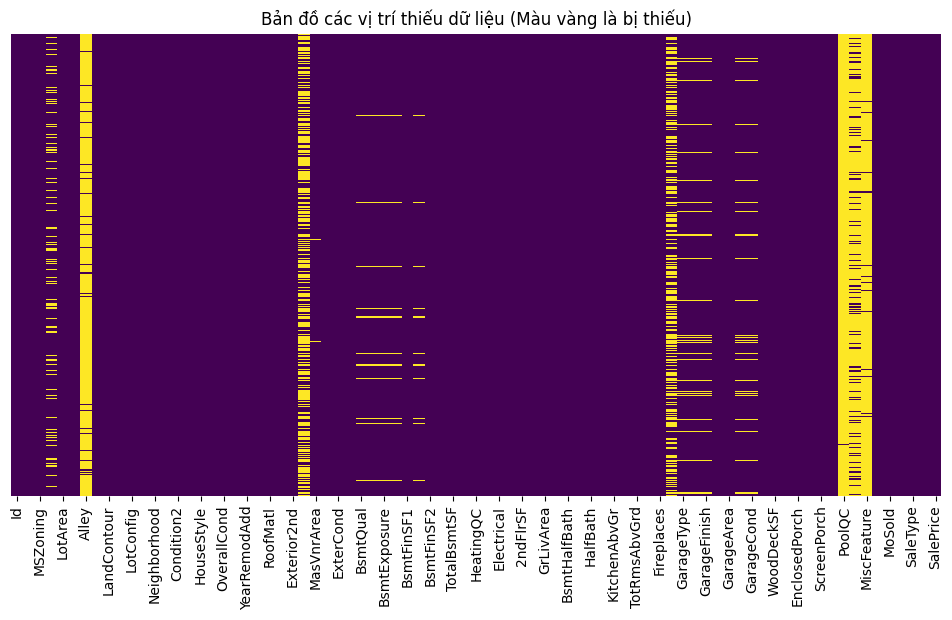

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Kiểm tra sơ bộ kích thước bảng (bao nhiêu hàng, bao nhiêu cột)
print(pd_train.shape)

# 2. Vẽ Heatmap để xem chỗ nào không có dữ liệu (Missing values)
plt.figure(figsize=(12, 6))
sns.heatmap(pd_train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Bản đồ các vị trí thiếu dữ liệu (Màu vàng là bị thiếu)')
plt.show()

In [13]:
# 1. Đếm số lượng giá trị null cho mỗi cột
null_counts = pd_train.isnull().sum()

# 2. Lọc ra các cột có ít nhất 1 giá trị null để dễ quan sát
missing_data = null_counts[null_counts > 0].sort_values(ascending=False)

# 3. Tính thêm tỉ lệ % để dễ đưa ra quyết định (Xóa hay Bổ sung)
missing_percentage = (null_counts[null_counts > 0] / len(pd_train) * 100).sort_values(ascending=False)

# 4. Hiển thị kết quả dưới dạng bảng
missing_report = pd.DataFrame({'Số dòng thiếu': missing_data, 'Tỉ lệ (%)': missing_percentage})
print(missing_report)

              Số dòng thiếu  Tỉ lệ (%)
PoolQC                 1453  99.520548
MiscFeature            1406  96.301370
Alley                  1369  93.767123
Fence                  1179  80.753425
MasVnrType              872  59.726027
FireplaceQu             690  47.260274
LotFrontage             259  17.739726
GarageType               81   5.547945
GarageYrBlt              81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
GarageCond               81   5.547945
BsmtExposure             38   2.602740
BsmtFinType2             38   2.602740
BsmtQual                 37   2.534247
BsmtCond                 37   2.534247
BsmtFinType1             37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493


In [14]:
# Xóa các cột thiếu quá nhiều (>=50%)
pd_train.drop(['Alley', 'PoolQC', 'MiscFeature', 'Fence','MasVnrType','FireplaceQu'], axis=1, inplace=True)

(1460, 75)


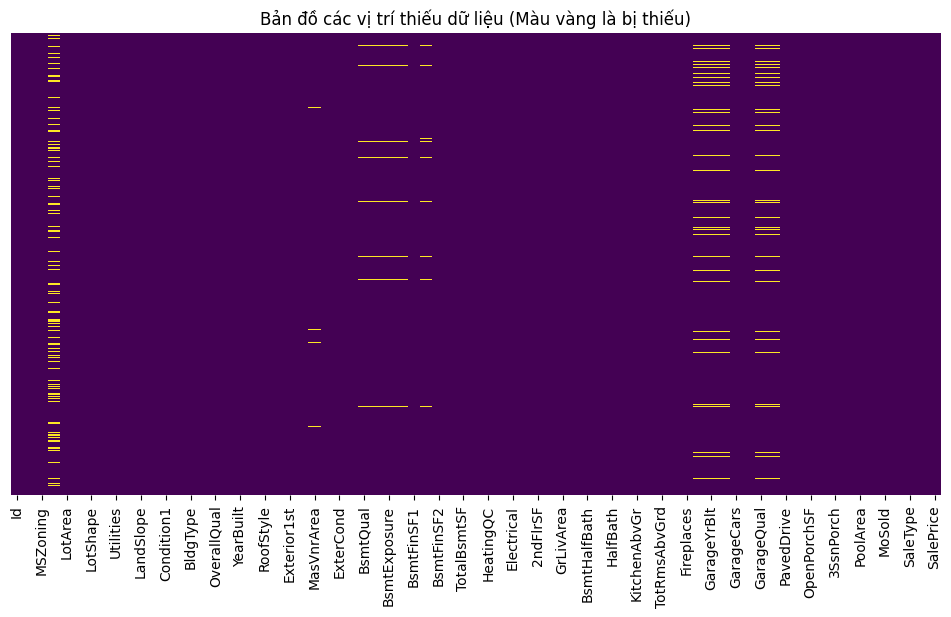

In [15]:
#Xem lại bản đồ nhiệt
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Kiểm tra sơ bộ kích thước bảng (bao nhiêu hàng, bao nhiêu cột)
print(pd_train.shape)

# 2. Vẽ Heatmap để xem chỗ nào không có dữ liệu (Missing values)
plt.figure(figsize=(12, 6))
sns.heatmap(pd_train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Bản đồ các vị trí thiếu dữ liệu (Màu vàng là bị thiếu)')
plt.show()

In [16]:
#hiển thị lại số dòng trên mỗi cột
# 1. Đếm số lượng giá trị null cho mỗi cột
null_counts = pd_train.isnull().sum()

# 2. Lọc ra các cột có ít nhất 1 giá trị null để dễ quan sát
missing_data = null_counts[null_counts > 0].sort_values(ascending=False)

# 3. Tính thêm tỉ lệ % để dễ đưa ra quyết định (Xóa hay Bổ sung)
missing_percentage = (null_counts[null_counts > 0] / len(pd_train) * 100).sort_values(ascending=False)

# 4. Hiển thị kết quả dưới dạng bảng
missing_report = pd.DataFrame({'Số dòng thiếu': missing_data, 'Tỉ lệ (%)': missing_percentage})
print(missing_report)

              Số dòng thiếu  Tỉ lệ (%)
LotFrontage             259  17.739726
GarageYrBlt              81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
GarageType               81   5.547945
GarageCond               81   5.547945
BsmtFinType2             38   2.602740
BsmtExposure             38   2.602740
BsmtQual                 37   2.534247
BsmtFinType1             37   2.534247
BsmtCond                 37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493


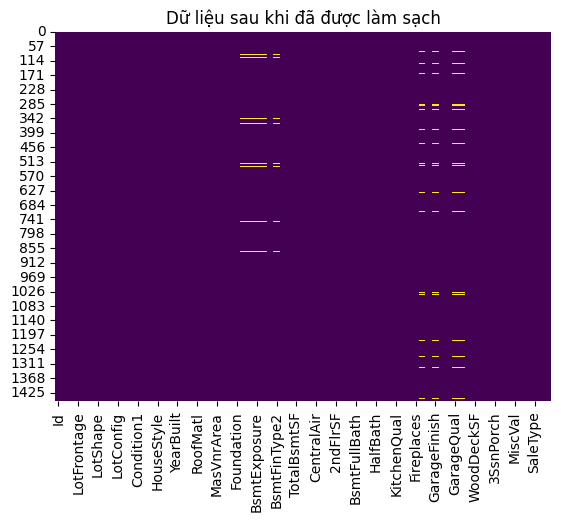

In [17]:
#Tiếp tục Cột số (Numerical): LotFrontage, GarageYrBlt, MasVnrArea.

# Cách thức: Điền bằng giá trị Median (trung vị). dùng Median thay vì Mean vì Median không bị ảnh hưởng bởi các điểm ngoại lai (outliers).
numeric_cols = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']
for col in numeric_cols:
    pd_train[col] = pd_train[col].fillna(pd_train[col].median())

# Kiểm tra lại bằng Heatmap một lần nữa
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(pd_train.isnull(), cbar=False, cmap='viridis')
plt.title("Dữ liệu sau khi đã được làm sạch các cột số")
plt.show()

Đã điền 'None' cho các cột đặc tính nhà và 'Mode' cho cột Electrical.


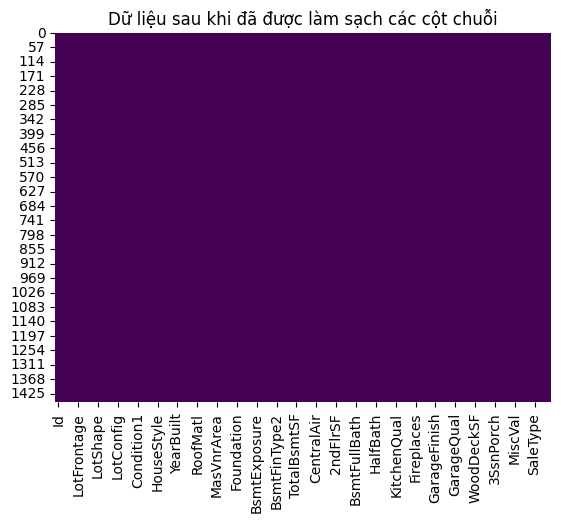

In [18]:
# Xử lý các cột có kiểu dữ liệu chuỗi
# 1. Danh sách các cột chữ cần điền "None"
categorical_cols_to_none = [
    'GarageFinish', 'GarageType', 'GarageQual', 'GarageCond',
    'BsmtExposure', 'BsmtFinType2', 'BsmtCond', 'BsmtQual', 'BsmtFinType1'
]

# 2. Điền "None" thay vì Mode
for col in categorical_cols_to_none:
    pd_train[col] = pd_train[col].fillna("None")

# 3. Riêng cột 'Electrical' thường mỗi nhà đều phải có điện,
# nên ta vẫn nên điền bằng giá trị phổ biến nhất (Mode)
pd_train['Electrical'] = pd_train['Electrical'].fillna(pd_train['Electrical'].mode()[0])

print("Đã điền 'None' cho các cột đặc tính nhà và 'Mode' cho cột Electrical.")
# Kiểm tra lại bằng Heatmap một lần nữa
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(pd_train.isnull(), cbar=False, cmap='viridis')
plt.title("Dữ liệu sau khi đã được làm sạch các cột chuỗi")
plt.show()